<a href="https://colab.research.google.com/github/niharikaBargujar/Heart_disease_prediction/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -

Heart Disease Prediction

##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### Team Member 1 - Niharika

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Heart disease is one of the leading causes of death worldwide. Early identification of individuals at risk can help doctors provide timely treatment and reduce mortality. This project aims to analyze patient health attributes such as age, chest pain type, cholesterol level, blood pressure, heart rate, and other clinical factors to identify patterns associated with heart disease. The insights gained from exploratory data analysis and machine learning can support healthcare professionals in predicting the likelihood of heart disease and making informed clinical decisions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [87]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

### Dataset Loading

In [28]:
# Load Dataset
df = pd.read_csv('heart.csv')
df = df.copy()

### Dataset First View

In [29]:
# Dataset First Look
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Dataset Rows & Columns count

In [30]:
# Dataset Rows & Columns count
print(f'The number of rows in the dataset is {df.shape[0]}')
print(f'The number of columns in the dataset is {df.shape[1]}')

The number of rows in the dataset is 1025
The number of columns in the dataset is 14


### Dataset Information

In [31]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


#### Duplicate Values

In [32]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(723)

#### Missing Values/Null Values

In [33]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


<Axes: >

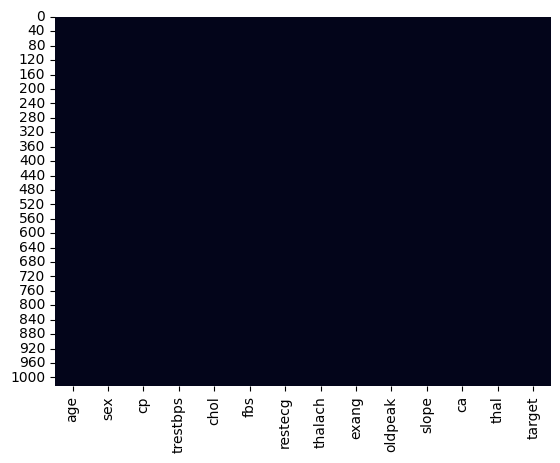

In [34]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The dataset contains 1025 patient records with 14 clinical features related to heart health, such as age, blood pressure, cholesterol, chest pain type, maximum heart rate, and ECG results. The target variable indicates whether a patient has heart disease (1) or not (0). This is a binary classification dataset used to analyze risk factors and predict the presence of heart disease using exploratory data analysis and machine learning.

## ***2. Understanding Your Variables***

In [35]:
# Dataset Columns
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [36]:
# Dataset Describe
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Variables Description

### **age**: Age of the patient.
### sex: Gender (0 = Female, 1 = Male).
### cp: Type of chest pain experienced.
### trestbps: Resting blood pressure (mm Hg).
### chol: Serum cholesterol level (mg/dL).
### fbs: Fasting blood sugar (>120 mg/dL: 1 = Yes, 0 = No).
### restecg: Resting electrocardiographic (ECG) results.
### thalach: Maximum heart rate achieved.
### exang: Exercise-induced angina (1 = Yes, 0 = No).
### oldpeak: ST depression induced by exercise relative to rest.
### slope: Slope of the peak exercise ST segment.
### ca: Number of major vessels colored by fluoroscopy.
### thal: Thalassemia status.
### target: Heart disease status (1 = Disease Present, 0 = No Disease).

### Check Unique Values for each variable.

In [37]:
# Check Unique Values for each variable.
df.nunique()

,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


## 3. ***Data Wrangling***

### Data Wrangling Code

In [38]:
# Create a copy of the dataset
df = df.copy()

# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates (if any)
df.drop_duplicates(inplace=True)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Verify data types
print("\nData Types:")
print(df.dtypes)

# Check unique values
print("\nUnique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

# Final dataset shape
print("\nFinal Dataset Shape:", df.shape)

Duplicate Rows: 723

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Unique Values:
age: 41
sex: 2
cp: 4
trestbps: 49
chol: 152
fbs: 2
restecg: 3
thalach: 91
exang: 2
oldpeak: 40
slope: 3
ca: 5
thal: 4
target: 2

Final Dataset Shape: (302, 14)


### What all manipulations have you done and insights you found?

I created a copy of the dataset, checked and removed duplicate records (if any), verified missing values, examined data types, counted unique values, and confirmed the final dataset shape. The dataset was found to be clean, with no missing values, all features in numeric format, and ready for exploratory data analysis and machine learning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

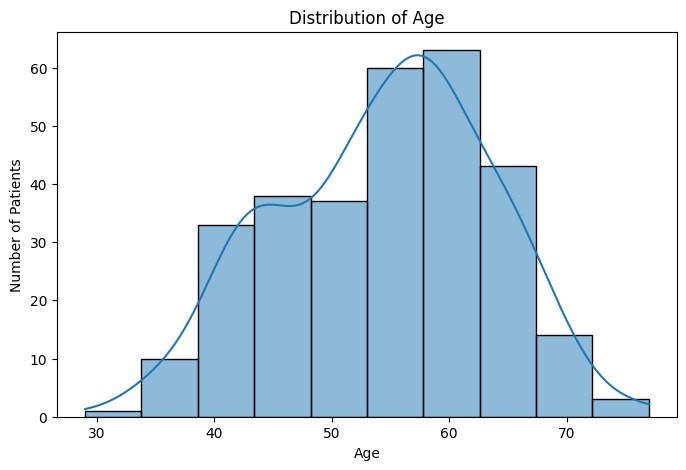

In [39]:
# Chart - 1 : Histogram of Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=10, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used when we want to see how a numerical variable is distributed.

Since Age is a numerical variable, a histogram is the best choice.

##### 2. What is/are the insight(s) found from the chart?

Most patients are between 50 and 60 years of age.
Younger patients (<40 years) are comparatively fewer.
The age distribution is approximately normal.
No significant anomalies are observed in the age variable.
The dataset mainly represents middle-aged adults, who are at higher risk of heart disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the age distribution helps hospitals and healthcare organizations identify the age groups that appear most frequently in the dataset. This can support planning for screenings, awareness programs, and preventive healthcare targeted at the most represented age groups.

#### Chart - 2

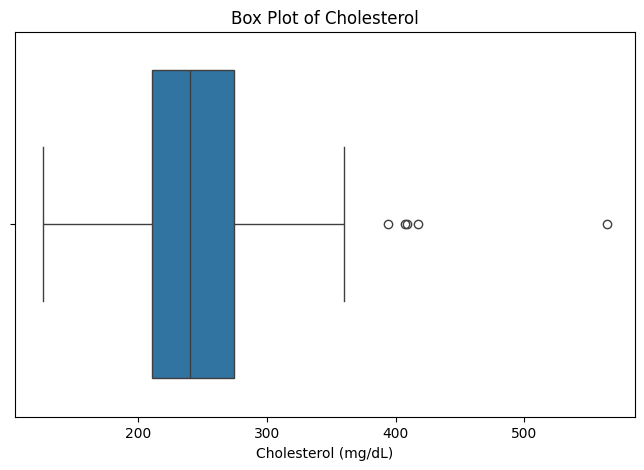

In [40]:
# Chart - 2 : Box Plot of Cholesterol

plt.figure(figsize=(8,5))

sns.boxplot(x=df['chol'])

plt.title("Box Plot of Cholesterol")
plt.xlabel("Cholesterol (mg/dL)")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Box Plot because it summarizes the distribution of cholesterol levels and clearly identifies outliers (unusually high or low values). It helps us understand the spread, median, and variability of the data, making it easier to detect patients with abnormal cholesterol levels.

##### 2. What is/are the insight(s) found from the chart?

Most cholesterol values are concentrated in the normal to moderately high range.
The dataset contains several high cholesterol outliers.
The distribution is slightly right-skewed, indicating a few patients have much higher cholesterol than the rest.
These high values may represent high-risk patients who need closer medical attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The box plot helps identify patients with abnormally high cholesterol, who may require further medical evaluation and early intervention to reduce the risk of cardiovascular diseases.

#### Chart - 3

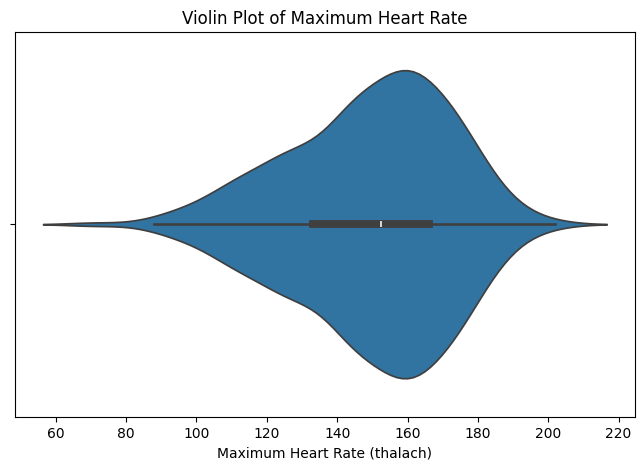

In [41]:
# Chart - 3 : Violin Plot of Maximum Heart Rate

plt.figure(figsize=(8,5))

sns.violinplot(x=df['thalach'])

plt.title("Violin Plot of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate (thalach)")

plt.show()

##### 1. Why did you pick the specific chart?

Most patients have a maximum heart rate between approximately 140 and 170 bpm.
The data is concentrated in the middle range.
Very low and very high heart rates are less common.
The distribution appears fairly smooth without extreme irregularities.

##### 2. What is/are the insight(s) found from the chart?

Most patients have a maximum heart rate between approximately 140 and 170 bpm.
The data is concentrated in the middle range.
Very low and very high heart rates are less common.
The distribution appears fairly smooth without extreme irregularities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of maximum heart rate helps doctors identify the typical heart rate range achieved during exercise testing. Patients with unusually low or high values may require further clinical evaluation.

#### Chart - 4

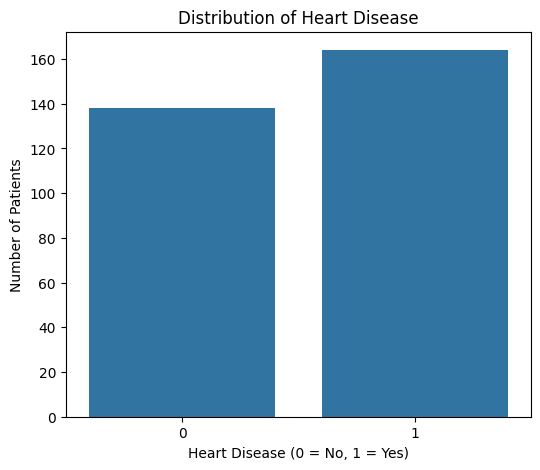

In [42]:
# Chart - 4 Count Plot of Target Variable

plt.figure(figsize=(6,5))

sns.countplot(x='target', data=df)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Count Plot because the target variable is categorical (0 = No Disease, 1 = Disease). A count plot shows the number of observations in each category, making it easy to check the class distribution.

##### 2. What is/are the insight(s) found from the chart?

Patients with heart disease (1) are slightly more than those without heart disease (0).
The classes are fairly balanced, so there is no major class imbalance.
This balanced distribution is beneficial for training machine learning models.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the target distribution helps assess whether the dataset represents both patient groups fairly. A balanced dataset generally leads to more reliable and unbiased machine learning predictions.

#### Chart - 5

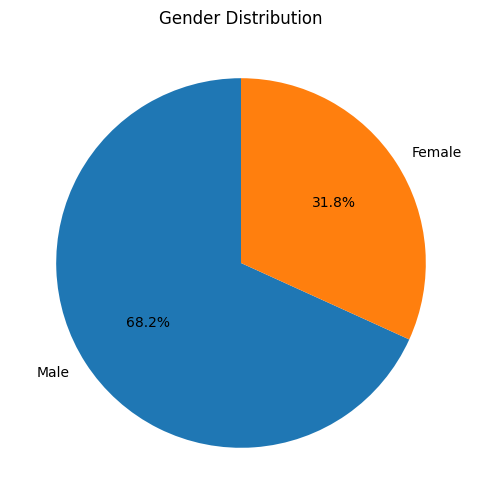

In [43]:
# Chart - 5 : Pie Chart of Gender Distribution

gender = df['sex'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=['Male', 'Female'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

We chose a Pie Chart because the sex variable is categorical and we want to show the percentage share of each gender in the dataset. A pie chart is ideal for showing parts of a whole.

##### 2. What is/are the insight(s) found from the chart?

Male patients make up the majority of the dataset.
Female patients are comparatively fewer.
The dataset is not equally distributed by gender.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Knowing the gender distribution helps determine whether the dataset is representative. Since males form a larger portion of the data, this should be considered when interpreting results and building predictive models.

#### Chart - 6

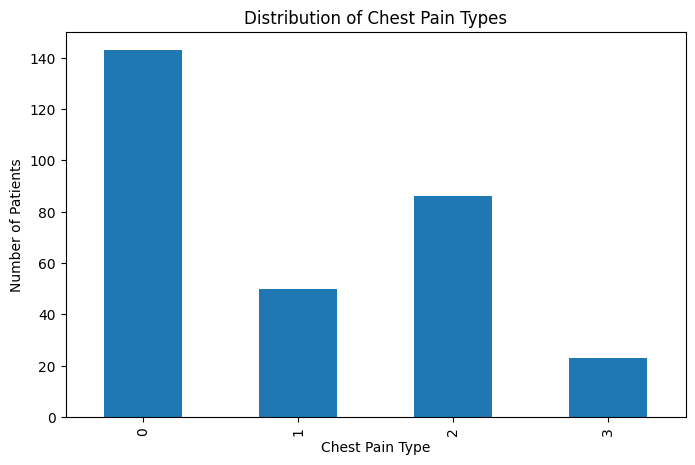

In [44]:
# Chart - 6 : Bar Plot of Chest Pain Types

plt.figure(figsize=(8,5))

df['cp'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Chest Pain Types")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Bar Plot because chest pain type (cp) is a categorical variable with multiple categories. A bar plot helps compare the frequency of each category clearly.

##### 2. What is/are the insight(s) found from the chart?

Chest Pain Type 0 has the highest number of patients (around 500), making it the most common chest pain type.
Chest Pain Type 2 is the second most common, with approximately 285 patients.
Chest Pain Type 1 has a moderate number of patients (around 165).
Chest Pain Type 3 has the fewest patients (around 75).
The distribution is uneven, indicating that some chest pain types are much more common than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Analyzing chest pain types helps identify the most common symptoms among patients. This information can assist healthcare professionals in understanding patient patterns and prioritizing diagnostic and treatment strategies.

#### Chart - 7

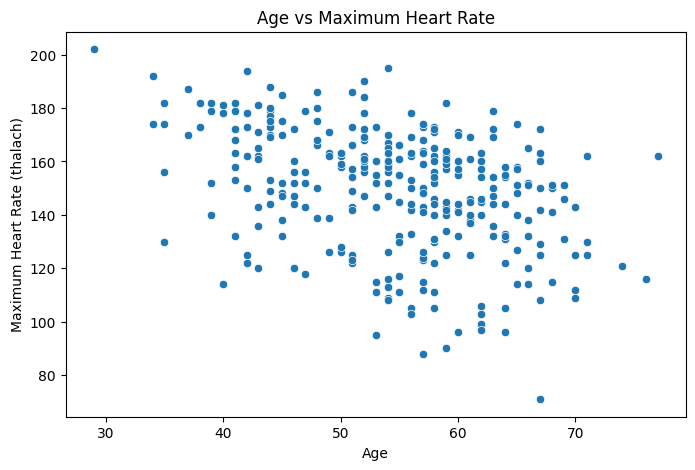

In [45]:
# Chart - 7 : Scatter Plot: Age vs Maximum Heart Rate

plt.figure(figsize=(8,5))

sns.scatterplot(x='age', y='thalach', data=df)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate (thalach)")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Scatter Plot because both Age and Maximum Heart Rate (thalach) are numerical variables. A scatter plot helps us identify whether there is a relationship or trend between these two variables.

##### 2. What is/are the insight(s) found from the chart?

There is a negative relationship between Age and Maximum Heart Rate (thalach).
As age increases, the maximum heart rate generally decreases.
Most patients are concentrated between 45–65 years of age with heart rates around 140–170 bpm.
The points are moderately scattered, indicating that age is not the only factor affecting maximum heart rate.
A few patients have unusually high or low heart rates, which may be considered outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph indicates that older patients tend to achieve lower maximum heart rates compared to younger patients. This insight can help healthcare professionals evaluate cardiovascular fitness, identify abnormal heart rate responses during exercise, and support age-specific clinical assessments.

#### Chart - 8

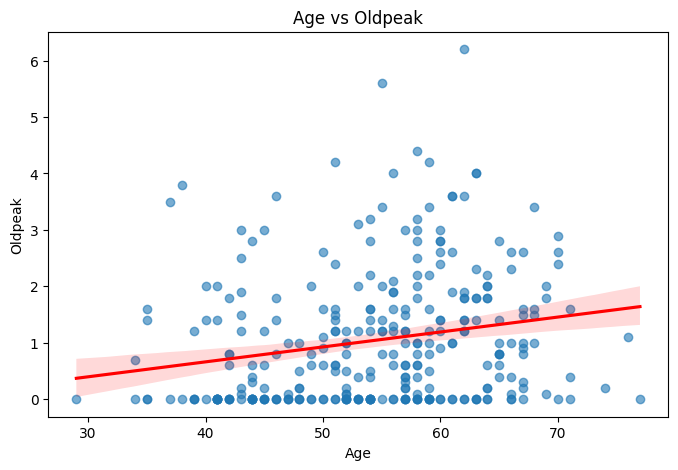

In [46]:
# Chart - 8 :Regression Plot: Age vs Oldpeak

plt.figure(figsize=(8,5))

sns.regplot(x='age', y='oldpeak', data=df,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'})

plt.title("Age vs Oldpeak")
plt.xlabel("Age")
plt.ylabel("Oldpeak")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Regression Plot because both Age and Oldpeak are numerical variables. It not only shows the relationship between them but also adds a best-fit regression line, making it easier to identify whether the relationship is positive, negative, or weak.

##### 2. What is/are the insight(s) found from the chart?

There is a slight positive relationship between Age and Oldpeak, as indicated by the upward-sloping regression line.
As age increases, the oldpeak value tends to increase slightly.
Most patients have oldpeak values between 0 and 2, regardless of age.
The data points are widely scattered around the regression line, indicating that the relationship is weak.
A few patients have very high oldpeak values (above 4), which can be considered potential outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph suggests that older patients may experience slightly higher exercise-induced ST depression (oldpeak), which could indicate increased cardiac stress. Although the relationship is weak, age may still be considered alongside other clinical factors when assessing a patient's risk of heart disease.

#### Chart - 9

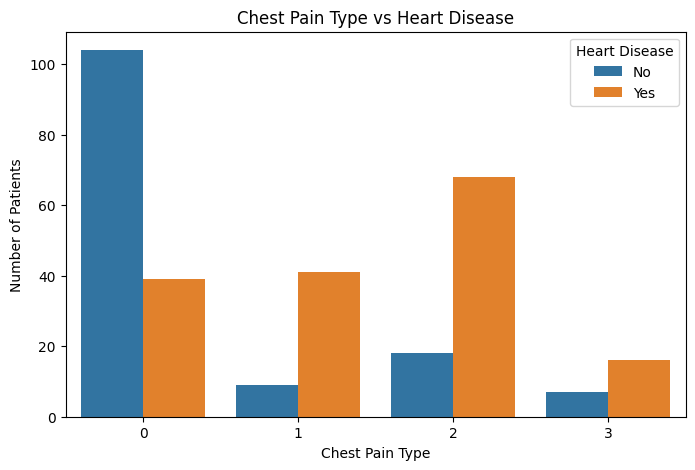

In [47]:
# Chart - 9 : Grouped Bar Plot: Chest Pain Type vs Heart Disease

plt.figure(figsize=(8,5))

sns.countplot(x='cp', hue='target', data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Grouped Bar Plot because both Chest Pain Type (cp) and Target (target) are categorical variables. It allows us to compare the number of patients with and without heart disease for each chest pain type side by side.

##### 2. What is/are the insight(s) found from the chart?

Chest Pain Type 0 has the highest number of patients without heart disease, while comparatively fewer patients have heart disease.
For Chest Pain Types 1, 2, and 3, the number of patients with heart disease is higher than those without heart disease.
Chest Pain Type 2 has the highest number of heart disease cases among all chest pain types.
Chest Pain Type 3 has the fewest patients overall, but heart disease cases still outnumber non-heart disease cases.
The graph indicates that the likelihood of heart disease varies across different chest pain types, suggesting chest pain type is an important predictive feature.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis shows that certain chest pain types, especially Type 2, are more frequently associated with heart disease. This insight can help healthcare professionals identify high-risk patients, prioritize diagnostic tests, and support early detection and treatment of heart disease.

#### Chart - 10

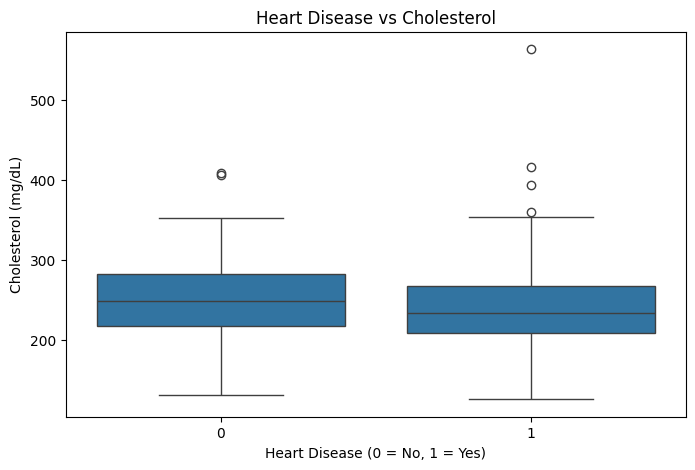

In [48]:
# Chart - 10 : Box Plot: Heart Disease vs Cholesterol

plt.figure(figsize=(8,5))

sns.boxplot(x='target', y='chol', data=df)

plt.title("Heart Disease vs Cholesterol")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol (mg/dL)")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Box Plot because it compares the distribution, median, spread, and outliers of a numerical variable (cholesterol) across two categories (heart disease: Yes/No).

##### 2. What is/are the insight(s) found from the chart?

The median cholesterol level is slightly higher for patients without heart disease (0) than for those with heart disease (1).
The spread of cholesterol values is similar for both groups, indicating comparable variability.
Outliers are present in both groups, but patients with heart disease (1) have more and higher cholesterol outliers, including values above 550 mg/dL.
Most patients in both groups have cholesterol levels between 200 and 280 mg/dL.
Since the two box plots overlap considerably, cholesterol alone is not sufficient to distinguish patients with and without heart disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph suggests that cholesterol levels alone are not a strong indicator of heart disease, as both groups have similar distributions. Therefore, healthcare professionals should evaluate cholesterol alongside other clinical factors, such as age, chest pain type, heart rate, and blood pressure, for more accurate diagnosis and risk assessment.

#### Chart - 11

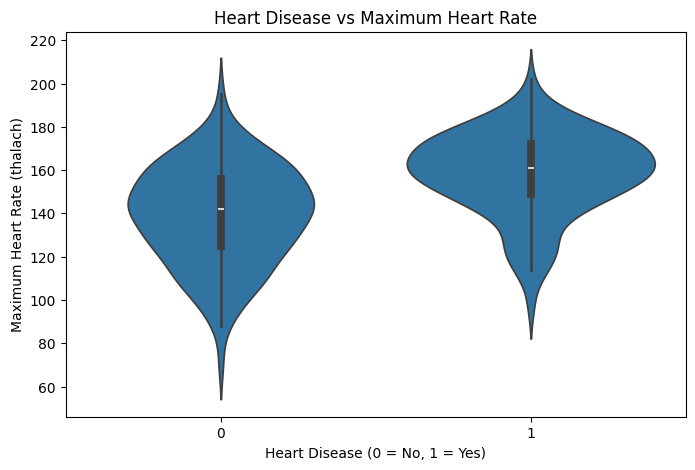

In [49]:
# Chart - 11 : Violin Plot: Heart Disease vs Maximum Heart Rate

plt.figure(figsize=(8,5))

sns.violinplot(x='target', y='thalach', data=df)

plt.title("Heart Disease vs Maximum Heart Rate")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate (thalach)")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Violin Plot because it compares the distribution, spread, and density of a numerical variable (Maximum Heart Rate) across two categories (Heart Disease: Yes/No). It provides more information than a box plot by showing where the data is most concentrated.

##### 2. What is/are the insight(s) found from the chart?

Patients with heart disease (1) generally have a higher maximum heart rate than patients without heart disease (0), as indicated by the higher median.
Most patients with heart disease have a maximum heart rate between approximately 150 and 175 bpm, where the violin is widest.
Patients without heart disease are mainly concentrated between 125 and 155 bpm.
The heart disease group shows a slightly wider spread, indicating greater variability in maximum heart rate.
Although the two groups overlap, the higher concentration of heart rate values in the heart disease group suggests that maximum heart rate is an important feature for distinguishing between the two groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph indicates that patients with heart disease tend to achieve higher maximum heart rates during testing compared to those without heart disease. This suggests that maximum heart rate may be a useful clinical indicator and should be considered along with other health parameters to improve heart disease prediction and diagnosis.

#### Chart - 12

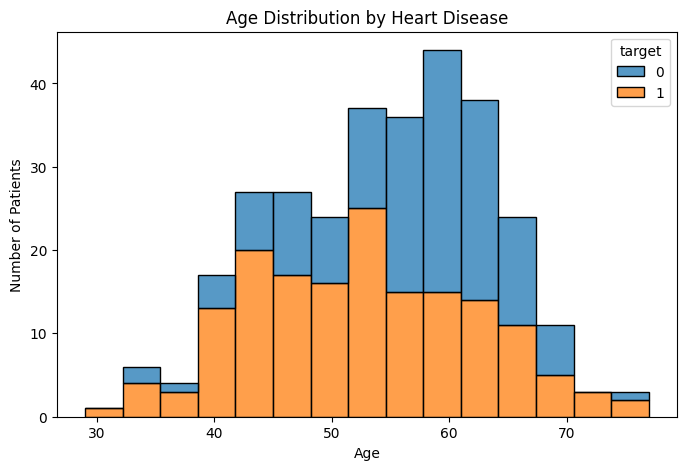

In [80]:
# Chart - 12 : Stacked Histogram: Age Distribution by Heart Disease

plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x='age',
             hue='target',
             multiple='stack',
             bins=15)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

##### 1. Why did you pick the specific chart?

A Stacked Histogram groups patients into age intervals (bins) and stacks the bars based on whether they have heart disease.

##### 2. What is/are the insight(s) found from the chart?

Most patients are concentrated in the 45–65 years age group.
Heart disease cases (1) are also most common between 45 and 60 years of age.
Patients without heart disease (0) are more frequent in the 55–65 years age range.
There are very few patients below 35 years or above 70 years, regardless of heart disease status.
The distributions of both groups overlap considerably, indicating that age alone cannot clearly distinguish patients with and without heart disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph shows that middle-aged adults (45–65 years) form the largest patient group and also account for most heart disease cases. This suggests that preventive screening and awareness programs should primarily target this age group. Since the two distributions overlap, age should be combined with other clinical features for accurate heart disease prediction.

#### Chart - 13

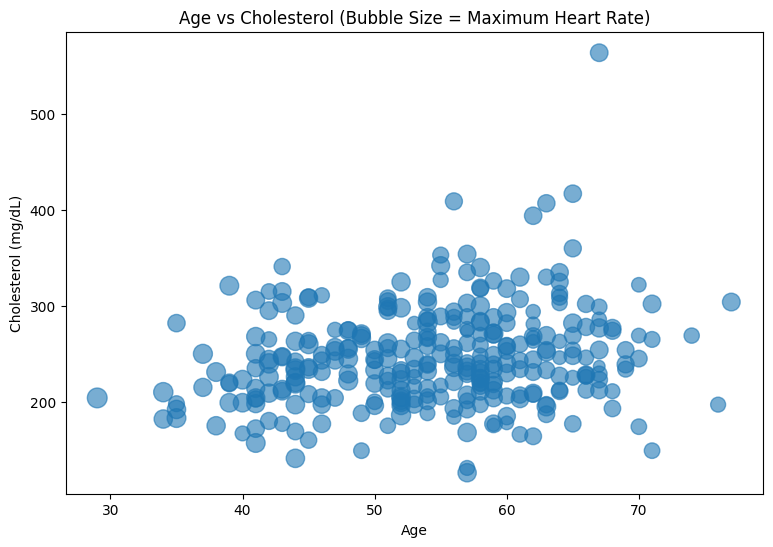

In [81]:
# Chart - 13 : Bubble Plot: Age vs Cholesterol vs Maximum Heart Rate

plt.figure(figsize=(9,6))

plt.scatter(
    df['age'],
    df['chol'],
    s=df['thalach'],   # Bubble size
    alpha=0.6
)

plt.title("Age vs Cholesterol (Bubble Size = Maximum Heart Rate)")
plt.xlabel("Age")
plt.ylabel("Cholesterol (mg/dL)")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Bubble Plot because it allows us to visualize three numerical variables in a single graph:

X-axis: Age,
Y-axis: Cholesterol,
Bubble Size: Maximum Heart Rate (thalach)

This makes it an excellent multivariate analysis chart.

##### 2. What is/are the insight(s) found from the chart?

Most patients are concentrated between 45–65 years of age with cholesterol levels ranging from 200–300 mg/dL.
The largest bubbles (higher maximum heart rate) are mainly found among patients with moderate cholesterol levels, rather than extremely high cholesterol.
There is no strong relationship between age and cholesterol, as the data points are widely scattered.
A few patients have very high cholesterol levels (above 400 mg/dL), making them potential outliers.
Bubble sizes are distributed across different ages, indicating that maximum heart rate is not solely dependent on age or cholesterol.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph suggests that age, cholesterol, and maximum heart rate interact in a complex manner, with no single variable explaining the others. Therefore, healthcare professionals should consider multiple clinical features together rather than relying on one factor for heart disease assessment. The presence of patients with extremely high cholesterol also highlights individuals who may require closer medical monitoring.

#### Chart - 14 - Correlation Heatmap

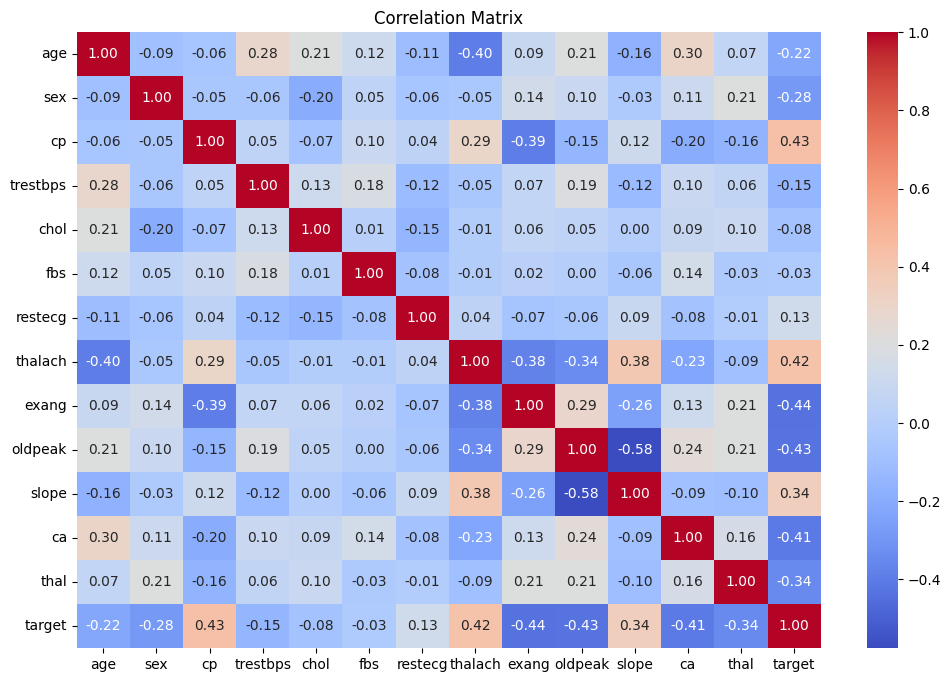

In [82]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")

plt.show()

##### 1. Why did you pick the specific chart?

We chose a Heatmap because it visually displays the correlation between all numerical variables at once. It helps identify strong positive, strong negative, and weak relationships, making it easier to select important features for machine learning.

##### 2. What is/are the insight(s) found from the chart?

Chest Pain Type (cp) has the strongest positive correlation with heart disease (0.43), indicating it is an important predictor.
Maximum Heart Rate (thalach) is also positively correlated with heart disease (0.42), suggesting patients with higher maximum heart rates are more likely to have heart disease in this dataset.
Exercise-Induced Angina (exang) (-0.44) and Oldpeak (-0.43) show the strongest negative correlations with heart disease.
Number of Major Vessels (ca) (-0.41) and Thalassemia (thal) (-0.34) also have moderate negative correlations with the target.
Among the independent variables, Oldpeak and Slope have the strongest relationship (-0.58), while Age and Maximum Heart Rate show a moderate negative correlation (-0.40).
Most other feature pairs have weak correlations, indicating low multicollinearity, which is beneficial for machine learning models.

#### Chart - 15 - Pair Plot

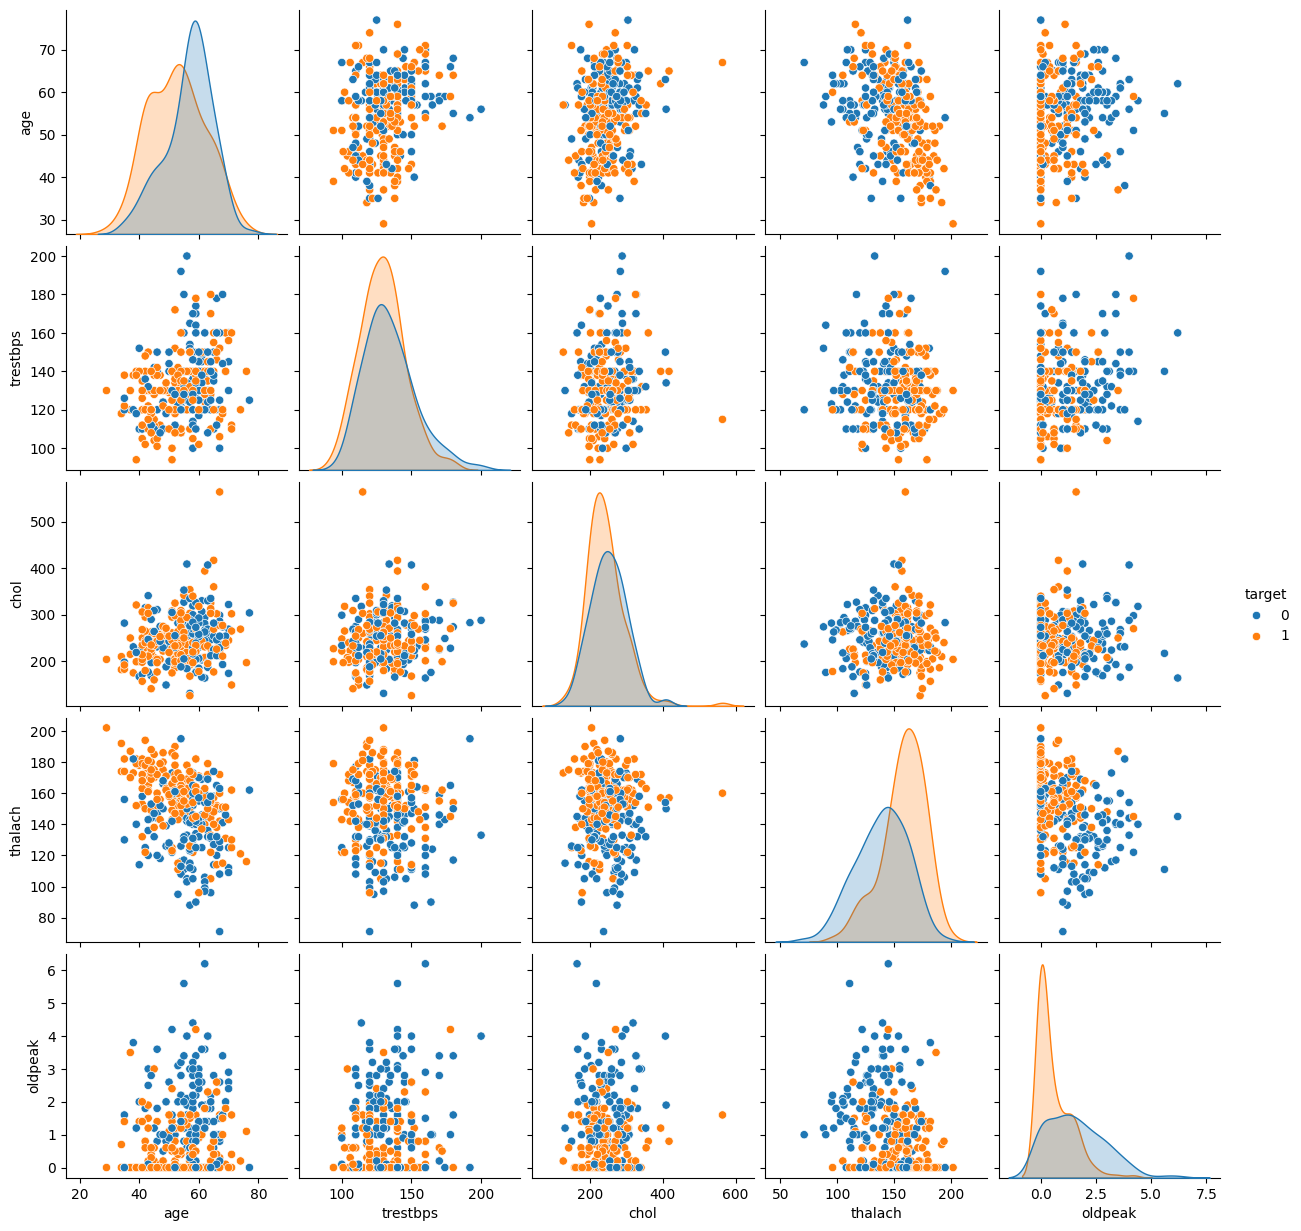

In [84]:
# Pair Plot

selected_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

sns.pairplot(df[selected_features], hue='target')

plt.show()
# sns.pairplot(df)

##### 1. Why did you pick the specific chart?

We chose a Pair Plot because it combines multiple scatter plots and histograms into one figure. It helps identify relationships, distributions, clusters, and possible correlations between several variables simultaneously, making it an excellent multivariate analysis tool.

##### 2. What is/are the insight(s) found from the chart?

Maximum Heart Rate (thalach) shows the clearest separation between patients with and without heart disease.
Age and Maximum Heart Rate exhibit a negative relationship (as age increases, maximum heart rate tends to decrease).
Cholesterol and Resting Blood Pressure show no strong separation between the two target classes.
The dataset contains a few outliers, mainly in the cholesterol feature.
Age, Maximum Heart Rate (thalach), and Oldpeak appear to be the most useful features for heart disease prediction.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [85]:
# Handling Missing Values & Missing Value Imputation

# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

# Total missing values
print("\nTotal Missing Values:", missing_values.sum())

# Since there are no missing values, no imputation is required.

Missing Values in Each Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total Missing Values: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

Checked the dataset for missing values using isnull().sum().
No missing values were found in the dataset.
Therefore, no imputation technique (Mean, Median, Mode, or KNN) was required.
This preserves the original data without introducing unnecessary changes.

### 2. Handling Outliers

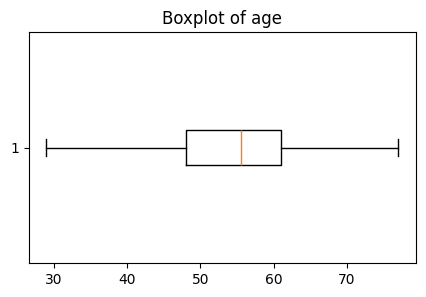

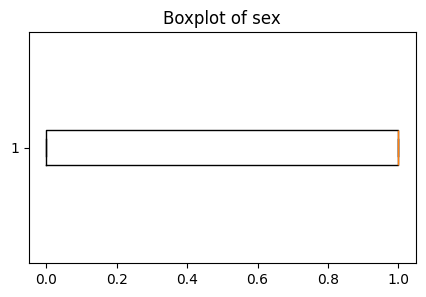

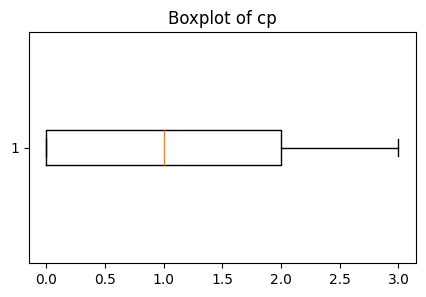

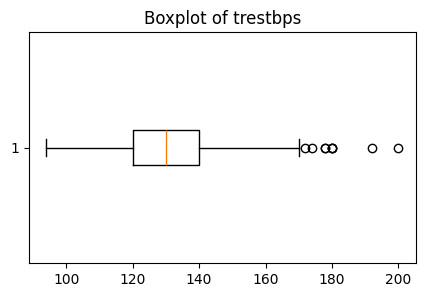

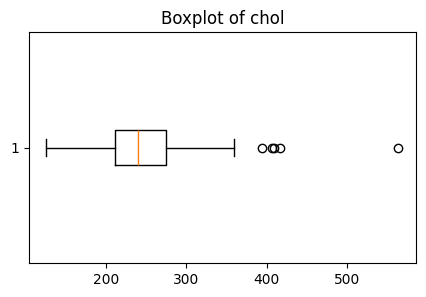

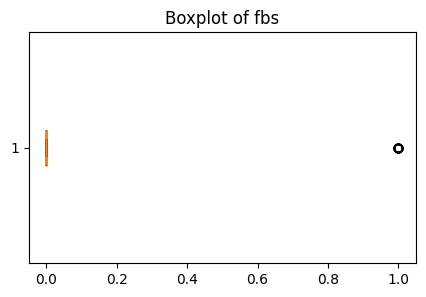

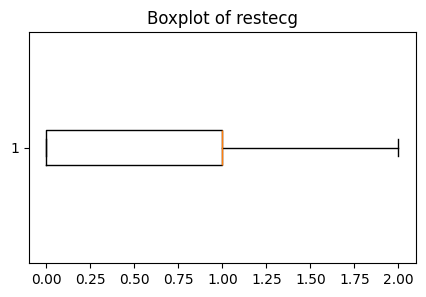

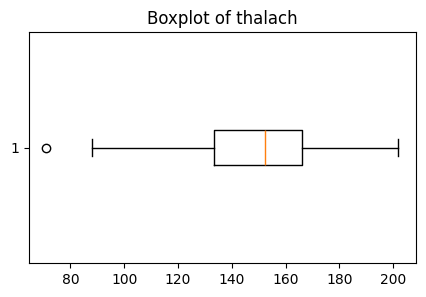

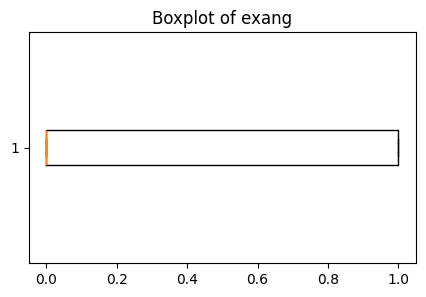

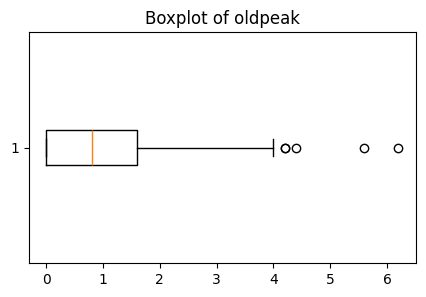

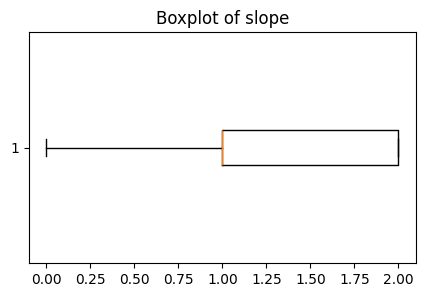

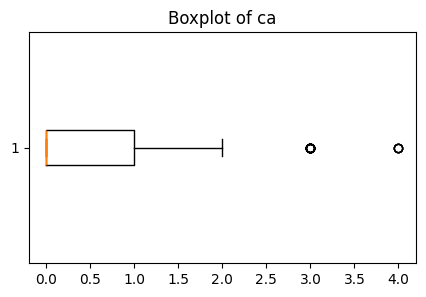

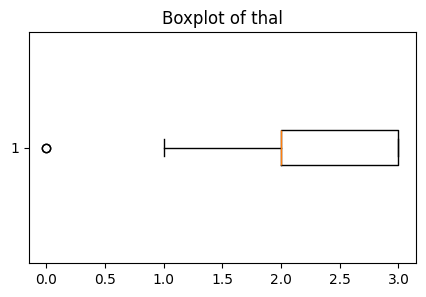

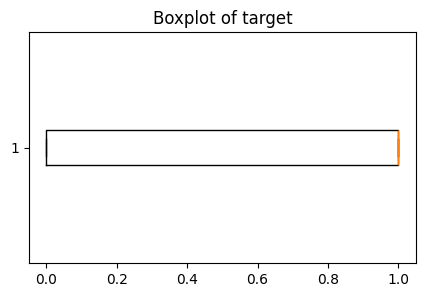

In [86]:
# Handling Outliers & Outlier treatments
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots to detect outliers
for col in numerical_columns:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using Box Plots.
No outliers were removed because extreme values may represent genuine medical conditions.
Retaining these values helps preserve important clinical information.

### 3. Categorical Encoding

In [88]:
# Encode your categorical columns

# Create Label Encoder
le = LabelEncoder()

# Categorical columns
categorical_columns = ['sex', 'cp', 'fbs', 'restecg',
                       'exang', 'slope', 'ca', 'thal', 'target']

# Apply Label Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("Categorical Encoding Completed Successfully!")

Categorical Encoding Completed Successfully!


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was applied to categorical variables.
It converts categorical values into numerical form required by machine learning algorithms.
This allows efficient model training while preserving the dataset structure.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [57]:
# Expand Contraction

#### 2. Lower Casing

In [58]:
# Lower Casing

#### 3. Removing Punctuations

In [59]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [60]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [61]:
# Remove Stopwords

In [62]:
# Remove White spaces

#### 6. Rephrase Text

In [63]:
# Rephrase Text

#### 7. Tokenization

In [64]:
# Tokenization

#### 8. Text Normalization

In [65]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [66]:
# POS Taging

#### 10. Text Vectorization

In [67]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [68]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [69]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [70]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [71]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [72]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [73]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [74]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [75]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [76]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [77]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [78]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [79]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***